# Model Development Experiment Notebook

This notebook builds a reproducible machine learning workflow using the fixed experiment split provided for the project.

Training CSV files: `ex_1.csv`, `ex_9.csv`, `ex_20.csv`, `ex_21.csv`, `ex_23.csv`, `ex_24.csv`.

Fixed test CSV files: `ex_4.csv`, `ex_22.csv`.

The requested evaluation suite is classification-oriented: accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and classification reports.

Important target note: the gas turbine files contain `time`, `input_voltage`, and continuous `el_power`. If `el_power` is continuous rather than a true class label, this notebook explicitly creates leakage-safe power-regime classes from training-set quantiles. That makes the classification workflow runnable without silently pretending the raw file already contains labels. For direct electrical power prediction, use a regression workflow instead.

## 1. Import Libraries

This cell imports data handling, visualization, preprocessing, model training, model tuning, evaluation, and model persistence utilities.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize
from sklearn.svm import LinearSVC

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print(f"XGBoost available: {XGBClassifier is not None}")
print(f"LightGBM available: {LGBMClassifier is not None}")

XGBoost available: True
LightGBM available: True


## 2. Dataset Loading - File Paths

The project stores CSV files in `micro gas turbine electrical energy prediction dataset/train` and `micro gas turbine electrical energy prediction dataset/test`.

In [2]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "micro gas turbine electrical energy prediction dataset"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

TRAIN_FILES = ["ex_1.csv", "ex_9.csv", "ex_20.csv", "ex_21.csv", "ex_23.csv", "ex_24.csv"]
TEST_FILES = ["ex_4.csv", "ex_22.csv"]

train_paths = [TRAIN_DIR / file_name for file_name in TRAIN_FILES]
test_paths = [TEST_DIR / file_name for file_name in TEST_FILES]

missing_paths = [path for path in train_paths + test_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing expected CSV files: " + ", ".join(str(path) for path in missing_paths))

## 3. Dataset Loading - Helper Function

Each CSV is loaded independently and annotated with its source file and experiment ID. This preserves the fixed experimental split and keeps file-level traceability throughout analysis.

In [3]:
def load_csv_with_metadata(file_path: Path, split_name: str) -> pd.DataFrame:
    """Load one CSV and attach experiment metadata."""
    frame = pd.read_csv(file_path)
    frame = frame.copy()
    frame["source_file"] = file_path.name
    frame["experiment_id"] = file_path.stem
    frame["split"] = split_name
    return frame

## 4. Load Training CSV Files

The training files are concatenated into one training DataFrame. No test data is used here.

In [4]:
train_frames = [load_csv_with_metadata(path, "train") for path in train_paths]
train_df = pd.concat(train_frames, ignore_index=True)

train_file_summary = train_df.groupby("source_file").size().rename("row_count").reset_index()
print(f"Combined training shape: {train_df.shape}")
display(train_file_summary)

Combined training shape: (52940, 6)


,source_file,row_count
0,ex_1.csv,9920
1,ex_20.csv,6495
2,ex_21.csv,6495
3,ex_23.csv,9188
4,ex_24.csv,9023
5,ex_9.csv,11819


## 5. Load Testing CSV Files

The fixed test files are concatenated into one test DataFrame and kept fully separate from the training data.

In [5]:
test_frames = [load_csv_with_metadata(path, "test") for path in test_paths]
test_df = pd.concat(test_frames, ignore_index=True)

test_file_summary = test_df.groupby("source_file").size().rename("row_count").reset_index()
print(f"Combined test shape: {test_df.shape}")
display(test_file_summary)

Combined test shape: (18285, 6)


,source_file,row_count
0,ex_22.csv,8490
1,ex_4.csv,9795


## 6. Combined DataFrame for EDA Only

The combined DataFrame is used only for inspection and visualization. Model fitting and preprocessing remain split into train and test to avoid leakage.

In [6]:
all_df = pd.concat([train_df, test_df], ignore_index=True)
print(f"All data shape: {all_df.shape}")
display(all_df.head())

All data shape: (71225, 6)


,time,input_voltage,el_power,source_file,experiment_id,split
0,810.07028,10.0,1228.791720,ex_1.csv,ex_1,train
1,811.06938,10.0,1223.041745,ex_1.csv,ex_1,train
2,812.06848,10.0,1244.960866,ex_1.csv,ex_1,train
3,813.06758,10.0,1229.259058,ex_1.csv,ex_1,train
4,814.06668,10.0,1248.117024,ex_1.csv,ex_1,train


## 7. Initial Dataset Inspection - Shape

In [7]:
shape_summary = pd.DataFrame(
    {
        "dataset": ["train", "test", "all"],
        "rows": [len(train_df), len(test_df), len(all_df)],
        "columns": [train_df.shape[1], test_df.shape[1], all_df.shape[1]],
    }
)
display(shape_summary)

,dataset,rows,columns
0,train,52940,6
1,test,18285,6
2,all,71225,6


## 8. Initial Dataset Inspection - Column Names

In [8]:
print("Training columns:")
print(list(train_df.columns))

print("\nTesting columns:")
print(list(test_df.columns))

all_columns = sorted(set(train_df.columns).union(test_df.columns))
column_alignment = pd.DataFrame(
    {
        "column": all_columns,
        "in_train": [col in train_df.columns for col in all_columns],
        "in_test": [col in test_df.columns for col in all_columns],
    }
)
display(column_alignment)

Training columns:
['time', 'input_voltage', 'el_power', 'source_file', 'experiment_id', 'split']

Testing columns:
['time', 'input_voltage', 'el_power', 'source_file', 'experiment_id', 'split']


,column,in_train,in_test
0,el_power,True,True
1,experiment_id,True,True
2,input_voltage,True,True
3,source_file,True,True
4,split,True,True
5,time,True,True


## 9. Initial Dataset Inspection - Data Types

In [9]:
dtype_summary = pd.DataFrame({"train_dtype": train_df.dtypes.astype(str), "test_dtype": test_df.dtypes.astype(str)})
display(dtype_summary)

,train_dtype,test_dtype
time,float64,float64
input_voltage,float64,float64
el_power,float64,float64
source_file,object,object
experiment_id,object,object
split,object,object


## 10. Initial Dataset Inspection - Missing Values

In [10]:
missing_summary = pd.DataFrame(
    {
        "train_missing_count": train_df.isna().sum(),
        "train_missing_pct": train_df.isna().mean() * 100,
        "test_missing_count": test_df.isna().sum(),
        "test_missing_pct": test_df.isna().mean() * 100,
    }
).sort_values("train_missing_pct", ascending=False)

display(missing_summary)

,train_missing_count,train_missing_pct,test_missing_count,test_missing_pct
time,0,0.0,0,0.0
input_voltage,0,0.0,0,0.0
el_power,0,0.0,0,0.0
source_file,0,0.0,0,0.0
experiment_id,0,0.0,0,0.0
split,0,0.0,0,0.0


## 11. Initial Dataset Inspection - Duplicate Rows

In [11]:
train_duplicate_count = train_df.duplicated().sum()
test_duplicate_count = test_df.duplicated().sum()

print(f"Duplicate rows in training set: {train_duplicate_count:,}")
print(f"Duplicate rows in test set:     {test_duplicate_count:,}")

Duplicate rows in training set: 0
Duplicate rows in test set:     0


## 12. Initial Dataset Inspection - Summary Statistics

In [12]:
display(train_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
time,52940.0,NaN,NaN,NaN,5606.444209,2960.330233,810.0,3086.93,5431.03389,7782.30137,12636.84
input_voltage,52940.0,NaN,NaN,NaN,5.505534,2.549721,3.0,3.0,4.842105,7.421053,10.0
el_power,52940.0,NaN,NaN,NaN,1843.315949,723.126377,932.83726,1205.7439,1605.753998,2399.419112,3249.891217
source_file,52940,6,ex_9.csv,11819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
experiment_id,52940,6,ex_9,11819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,52940,1,train,52940,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. Target Column Detection or Confirmation

The notebook checks common target names first. In this dataset, `el_power` is the obvious physical target if present. If that target is continuous, the notebook creates classification labels named `target_class` from training-set quantiles and applies the same bin edges to the test set.

This is intentionally explicit: the raw `el_power` target is not a native class label.

In [13]:
TARGET_CANDIDATES = ["target", "label", "class", "y", "outcome", "el_power"]

metadata_columns = {"source_file", "experiment_id", "split"}
common_model_columns = [col for col in train_df.columns if col in test_df.columns and col not in metadata_columns]

target_column = None
for candidate in TARGET_CANDIDATES:
    if candidate in common_model_columns:
        target_column = candidate
        break

if target_column is None:
    print("No obvious target column was detected from the common target-name candidates.")
    print("Available modeling columns:", common_model_columns)
    raise ValueError("Please set target_column manually after inspecting the columns.")

print(f"Detected target column: {target_column}")

raw_target = train_df[target_column]
raw_target_numeric = pd.api.types.is_numeric_dtype(raw_target)
raw_target_unique_count = raw_target.nunique(dropna=True)
raw_target_unique_ratio = raw_target_unique_count / max(len(raw_target), 1)

print(f"Target dtype: {raw_target.dtype}")
print(f"Unique target values in training set: {raw_target_unique_count:,}")
print(f"Unique-target ratio: {raw_target_unique_ratio:.4f}")

Detected target column: el_power
Target dtype: float64
Unique target values in training set: 52,940
Unique-target ratio: 1.0000


## 14. Classification Target Preparation

If the detected target is categorical or already label-like, it is used directly. If it is continuous numeric `el_power`, this notebook creates three power-regime classes using only training-set quantile cut points:

- low output power regime
- medium output power regime
- high output power regime

The same cut points are then applied to the fixed test set to avoid train-test leakage.

In [14]:
TARGET_CLASS_COLUMN = "target_class"
TARGET_CLASS_LABEL_COLUMN = "target_class_label"
N_POWER_REGIME_CLASSES = 3

continuous_target_detected = raw_target_numeric and raw_target_unique_count > max(20, int(0.02 * len(train_df)))

if continuous_target_detected:
    quantile_grid = np.linspace(0.0, 1.0, N_POWER_REGIME_CLASSES + 1)
    learned_edges = train_df[target_column].quantile(quantile_grid).to_numpy(dtype=float)
    learned_edges = np.unique(learned_edges)

    if len(learned_edges) < 3:
        learned_edges = np.unique(train_df[target_column].quantile([0.0, 0.5, 1.0]).to_numpy(dtype=float))

    if len(learned_edges) < 3:
        raise ValueError("The continuous target does not have enough variation to create classification bins.")

    bin_edges = learned_edges.copy()
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    class_ids = list(range(len(bin_edges) - 1))
    class_labels = [f"power_regime_{idx}" for idx in class_ids]

    train_df[TARGET_CLASS_COLUMN] = pd.cut(train_df[target_column], bins=bin_edges, labels=class_ids, include_lowest=True).astype(int)
    test_df[TARGET_CLASS_COLUMN] = pd.cut(test_df[target_column], bins=bin_edges, labels=class_ids, include_lowest=True).astype(int)

    train_df[TARGET_CLASS_LABEL_COLUMN] = train_df[TARGET_CLASS_COLUMN].map(dict(zip(class_ids, class_labels)))
    test_df[TARGET_CLASS_LABEL_COLUMN] = test_df[TARGET_CLASS_COLUMN].map(dict(zip(class_ids, class_labels)))

    model_target_column = TARGET_CLASS_COLUMN
    print(f"Detected continuous target '{target_column}'. Created classification target '{TARGET_CLASS_COLUMN}' using training quantile bin edges.")
    print("Training-derived bin edges used for classification:", bin_edges)
else:
    model_target_column = target_column
    print(f"Using detected target column '{target_column}' directly as a classification label.")

all_df = pd.concat([train_df, test_df], ignore_index=True)
display(train_df[[target_column, model_target_column]].head())

Detected continuous target 'el_power'. Created classification target 'target_class' using training quantile bin edges.
Training-derived bin edges used for classification: [         -inf 1265.87540484 2175.02490614           inf]


,el_power,target_class
0,1228.791720,0
1,1223.041745,0
2,1244.960866,0
3,1229.259058,0
4,1248.117024,0


## 15. Deep Exploratory Data Analysis - Class Distribution

The class distribution is inspected separately for training and test sets. If classes are heavily imbalanced, macro-averaged metrics and class weighting become more important than accuracy alone.

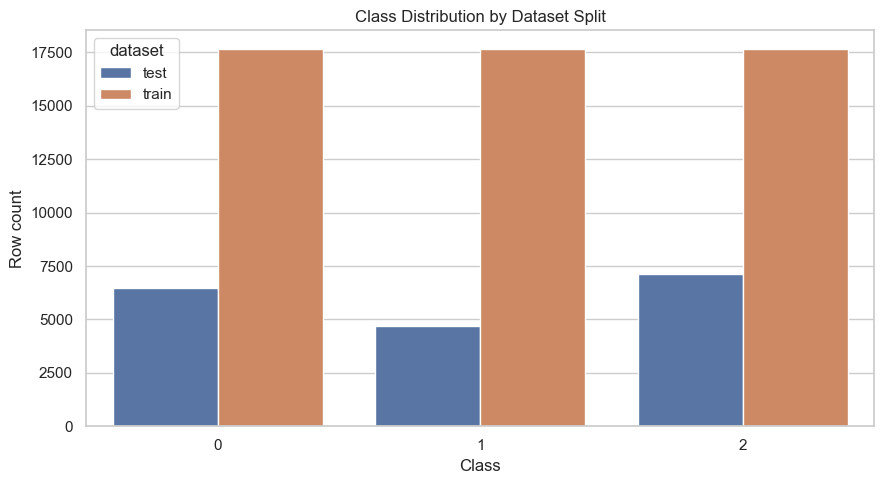

,dataset,target_class,count
0,test,0,6483
1,test,1,4684
2,test,2,7118
3,train,0,17647
4,train,1,17646
5,train,2,17647


In [15]:
class_distribution = (
    pd.concat([train_df.assign(dataset="train"), test_df.assign(dataset="test")], ignore_index=True)
    .groupby(["dataset", model_target_column])
    .size()
    .rename("count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=class_distribution, x=model_target_column, y="count", hue="dataset", ax=ax)
ax.set_title("Class Distribution by Dataset Split")
ax.set_xlabel("Class")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.show()

display(class_distribution)

### Class Distribution Interpretation

Use the plot above to check whether the training set contains enough examples from each class. If the distribution is uneven, prioritize macro F1-score, precision, recall, and ROC-AUC over accuracy.

## 16. Deep Exploratory Data Analysis - Feature Distributions

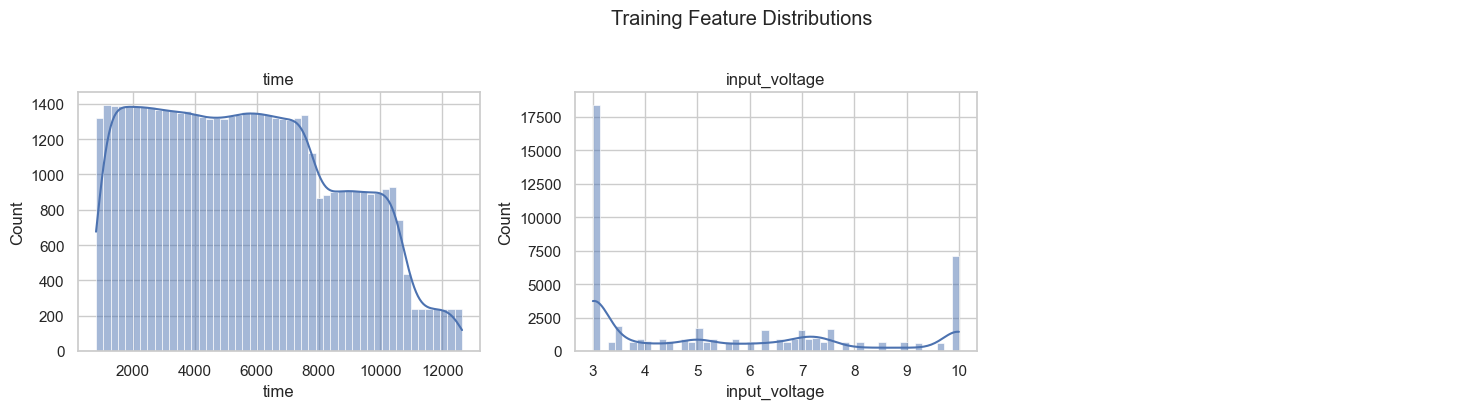

In [16]:
excluded_for_eda = {target_column, TARGET_CLASS_COLUMN, TARGET_CLASS_LABEL_COLUMN, "source_file", "split"}
feature_columns_for_eda = [col for col in train_df.columns if col not in excluded_for_eda]
numeric_eda_columns = train_df[feature_columns_for_eda].select_dtypes(include=[np.number]).columns.tolist()

if numeric_eda_columns:
    plot_columns = numeric_eda_columns[:12]
    n_cols = 3
    n_rows = int(np.ceil(len(plot_columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, plot_columns):
        sns.histplot(train_df[col].dropna(), kde=True, bins=50, ax=ax)
        ax.set_title(col)

    for ax in axes[len(plot_columns):]:
        ax.axis("off")

    fig.suptitle("Training Feature Distributions", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric feature columns found for distribution plots.")

### Feature Distribution Interpretation

Review skew, multimodality, and unusual spikes. For turbine experiments, step-like input controls often create discrete feature distributions rather than smooth bell-shaped distributions.

## 17. Deep Exploratory Data Analysis - Correlation Heatmap

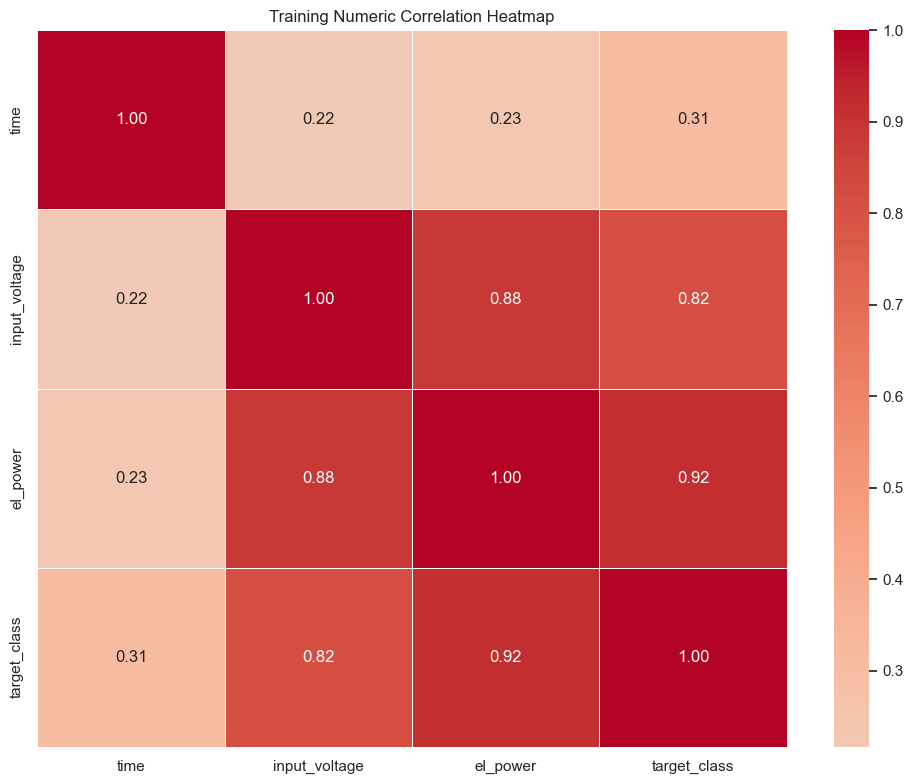

In [17]:
numeric_corr_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_corr_columns) >= 2:
    corr = train_df[numeric_corr_columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
    ax.set_title("Training Numeric Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a correlation heatmap.")

### Correlation Interpretation

Highly correlated features can help simple models but may create instability for linear coefficients. Tree-based models are usually less sensitive to feature collinearity.

## 18. Deep Exploratory Data Analysis - Possible Outlier Checks

,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
0,time,3086.93,7782.301370,4695.371370,-3956.127055,14825.358425,0,0.0
1,input_voltage,3.00,7.421053,4.421053,-3.631579,14.052632,0,0.0


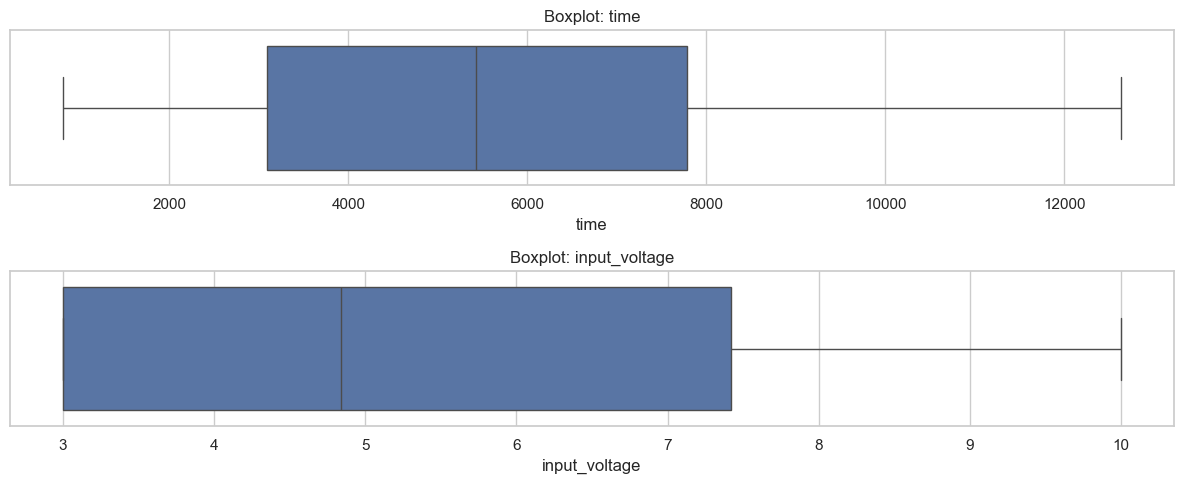

In [18]:
def iqr_outlier_summary(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        series = frame[col].dropna()
        if series.empty:
            continue
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((series < lower) | (series > upper)).sum())
        rows.append(
            {
                "column": col,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_fence": lower,
                "upper_fence": upper,
                "outlier_count": outlier_count,
                "outlier_pct": 100 * outlier_count / max(len(series), 1),
            }
        )
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

outlier_summary = iqr_outlier_summary(train_df, numeric_eda_columns)
display(outlier_summary)

if numeric_eda_columns:
    plot_columns = numeric_eda_columns[:8]
    fig, axes = plt.subplots(len(plot_columns), 1, figsize=(12, 2.5 * len(plot_columns)))
    if len(plot_columns) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_columns):
        sns.boxplot(x=train_df[col], ax=ax)
        ax.set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

## 19. Deep Exploratory Data Analysis - Categorical Feature Exploration

,experiment_id,count
0,ex_9,11819
1,ex_1,9920
2,ex_23,9188
3,ex_24,9023
4,ex_20,6495
5,ex_21,6495


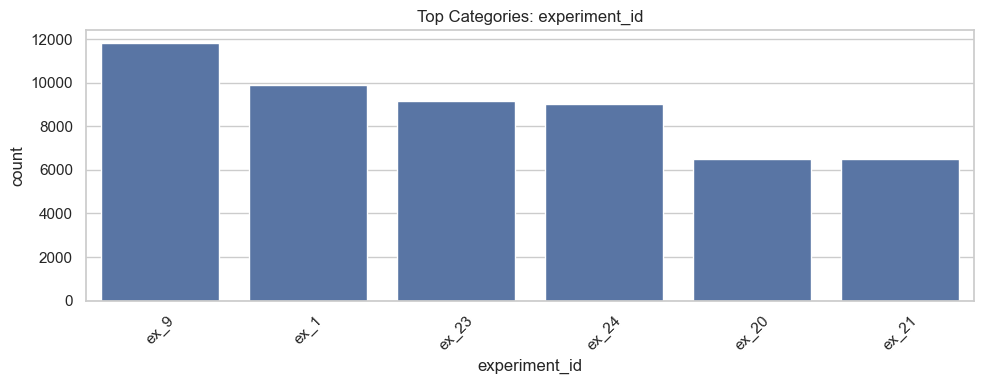

In [19]:
categorical_eda_columns = [
    col for col in feature_columns_for_eda
    if col in train_df.columns and not pd.api.types.is_numeric_dtype(train_df[col])
]

if categorical_eda_columns:
    for col in categorical_eda_columns[:8]:
        display(train_df[col].value_counts(dropna=False).head(20).rename_axis(col).reset_index(name="count"))
        fig, ax = plt.subplots(figsize=(10, 4))
        top_categories = train_df[col].value_counts(dropna=False).head(15).index
        sns.countplot(data=train_df[train_df[col].isin(top_categories)], x=col, order=top_categories, ax=ax)
        ax.set_title(f"Top Categories: {col}")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("No non-metadata categorical feature columns were found.")

## 20. Data Preprocessing - Feature and Target Split

Metadata columns and raw target columns are excluded from predictors. Preprocessing will be fit only on the training set.

In [20]:
excluded_model_columns = {target_column, TARGET_CLASS_COLUMN, TARGET_CLASS_LABEL_COLUMN, "source_file", "experiment_id", "split"}

feature_columns = [col for col in train_df.columns if col not in excluded_model_columns]

X_train_raw = train_df[feature_columns].copy()
X_test_raw = test_df[feature_columns].copy()
y_train_raw = train_df[model_target_column].copy()
y_test_raw = test_df[model_target_column].copy()

print("Feature columns used for modeling:")
print(feature_columns)
print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"X_test_raw shape:  {X_test_raw.shape}")

Feature columns used for modeling:
['time', 'input_voltage']
X_train_raw shape: (52940, 2)
X_test_raw shape:  (18285, 2)


## 21. Data Preprocessing - Encode Target Labels

The target labels are encoded numerically for classifier compatibility. The label mapping is preserved for reports and plots.

In [21]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw.astype(str))

unseen_test_labels = sorted(set(y_test_raw.astype(str)) - set(label_encoder.classes_))
if unseen_test_labels:
    raise ValueError(f"Test set contains labels unseen during training: {unseen_test_labels}")

y_test = label_encoder.transform(y_test_raw.astype(str))
class_names = label_encoder.classes_.tolist()
n_classes = len(class_names)

print("Encoded class mapping:")
for idx, class_name in enumerate(class_names):
    print(f"  {idx}: {class_name}")

if n_classes < 2:
    raise ValueError("Classification requires at least two classes in the training data.")

Encoded class mapping:
  0: 0
  1: 1
  2: 2


## 22. Data Preprocessing - Numeric and Categorical Column Detection

In [22]:
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_train_raw.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['time', 'input_voltage']
Categorical features: []


## 23. Data Preprocessing - Missing Values, Encoding, and Scaling

Two preprocessors are created:

- `preprocessor_scaled` for linear and SVM models
- `preprocessor_unscaled` for tree and boosting models

Both are fit inside sklearn pipelines using training data only.

In [23]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_scaled_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_unscaled_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ]
)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0.0,
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_unscaled_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0.0,
)

## 24. Data Preprocessing - Class Imbalance Handling

Class imbalance is checked from the training labels only. If imbalance is meaningful, compatible models use `class_weight='balanced'`.

In [24]:
class_count_series = pd.Series(y_train).value_counts().sort_index()
class_count_table = pd.DataFrame(
    {
        "encoded_class": class_count_series.index,
        "class_name": [class_names[idx] for idx in class_count_series.index],
        "count": class_count_series.values,
    }
)

min_class_count = int(class_count_series.min())
max_class_count = int(class_count_series.max())
imbalance_ratio = max_class_count / max(min_class_count, 1)
class_weight_strategy = "balanced" if imbalance_ratio >= 1.5 else None

print(f"Minimum class count: {min_class_count}")
print(f"Maximum class count: {max_class_count}")
print(f"Imbalance ratio:     {imbalance_ratio:.3f}")
print(f"Class weight mode:   {class_weight_strategy}")
display(class_count_table)

if min_class_count < 2:
    raise ValueError("At least one class has fewer than two samples; cross-validation is not reliable.")

Minimum class count: 17646
Maximum class count: 17647
Imbalance ratio:     1.000
Class weight mode:   None


,encoded_class,class_name,count
0,0,0,17647
1,1,1,17646
2,2,2,17647


## 25. Model Training Setup

Cross-validation uses stratified folds to preserve class proportions in each fold.

In [25]:
n_cv_splits = min(5, min_class_count)
cv = StratifiedKFold(n_splits=n_cv_splits, shuffle=True, random_state=RANDOM_STATE)

trained_models: dict[str, Any] = {}
tuning_results: dict[str, Any] = {}

print(f"Using {n_cv_splits}-fold stratified cross-validation.")

Using 5-fold stratified cross-validation.


## 26. Model Training - Logistic Regression

In [26]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight=class_weight_strategy,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_pipeline.fit(X_train_raw, y_train)
trained_models["Logistic Regression"] = logistic_pipeline
print("Trained Logistic Regression.")

Trained Logistic Regression.


## 27. Model Training - Random Forest

In [27]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_unscaled),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                class_weight=class_weight_strategy,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_pipeline.fit(X_train_raw, y_train)
trained_models["Random Forest"] = random_forest_pipeline
print("Trained Random Forest.")

Trained Random Forest.


## 28. Model Training - Gradient Boosting Baseline

In [28]:
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_unscaled),
        ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
)

gradient_boosting_pipeline.fit(X_train_raw, y_train)
trained_models["Gradient Boosting"] = gradient_boosting_pipeline
print("Trained Gradient Boosting baseline.")

Trained Gradient Boosting baseline.


## 29. Model Training - Support Vector Machine

A calibrated linear SVM is used so ROC-AUC can be computed from class probabilities.

In [29]:
base_linear_svm = LinearSVC(
    C=1.0,
    class_weight=class_weight_strategy,
    random_state=RANDOM_STATE,
    max_iter=5000,
)

calibrated_svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            CalibratedClassifierCV(
                estimator=base_linear_svm,
                cv=min(3, n_cv_splits),
                method="sigmoid",
            ),
        ),
    ]
)

calibrated_svm_pipeline.fit(X_train_raw, y_train)
trained_models["Calibrated Linear SVM"] = calibrated_svm_pipeline
print("Trained calibrated Linear SVM.")

Trained calibrated Linear SVM.


## 30. Model Training - XGBoost

This cell is skipped automatically if XGBoost is not installed.

In [30]:
if XGBClassifier is not None:
    xgb_objective = "binary:logistic" if n_classes == 2 else "multi:softprob"
    xgb_eval_metric = "logloss" if n_classes == 2 else "mlogloss"

    xgb_classifier = XGBClassifier(
        objective=xgb_objective,
        eval_metric=xgb_eval_metric,
        num_class=n_classes if n_classes > 2 else None,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_unscaled),
            ("classifier", xgb_classifier),
        ]
    )

    xgb_pipeline.fit(X_train_raw, y_train)
    trained_models["XGBoost"] = xgb_pipeline
    print("Trained XGBoost.")
else:
    print("XGBoost is not installed. Skipping XGBoost model.")

Trained XGBoost.


## 31. Model Training - LightGBM

This cell is skipped automatically if LightGBM is not installed.

In [31]:
if LGBMClassifier is not None:
    lgbm_objective = "binary" if n_classes == 2 else "multiclass"

    lgbm_classifier = LGBMClassifier(
        objective=lgbm_objective,
        num_class=n_classes if n_classes > 2 else None,
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight=class_weight_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

    lgbm_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_unscaled),
            ("classifier", lgbm_classifier),
        ]
    )

    lgbm_pipeline.fit(X_train_raw, y_train)
    trained_models["LightGBM"] = lgbm_pipeline
    print("Trained LightGBM.")
else:
    print("LightGBM is not installed. Skipping LightGBM model.")

Trained LightGBM.


## 32. Hyperparameter Tuning - Logistic Regression

In [32]:
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__solver": ["lbfgs"],
}

logistic_search = GridSearchCV(
    estimator=clone(logistic_pipeline),
    param_grid=logistic_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

logistic_search.fit(X_train_raw, y_train)
trained_models["Tuned Logistic Regression"] = logistic_search.best_estimator_
tuning_results["Tuned Logistic Regression"] = logistic_search

print("Best Logistic Regression parameters:", logistic_search.best_params_)
print("Best CV macro F1:", logistic_search.best_score_)

Best Logistic Regression parameters: {'classifier__C': 10.0, 'classifier__solver': 'lbfgs'}
Best CV macro F1: 0.8607923776991558


## 33. Hyperparameter Tuning - Random Forest

In [33]:
random_forest_param_dist = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
    "classifier__max_features": ["sqrt", "log2", None],
}

random_forest_search = RandomizedSearchCV(
    estimator=clone(random_forest_pipeline),
    param_distributions=random_forest_param_dist,
    n_iter=12,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

random_forest_search.fit(X_train_raw, y_train)
trained_models["Tuned Random Forest"] = random_forest_search.best_estimator_
tuning_results["Tuned Random Forest"] = random_forest_search

print("Best Random Forest parameters:", random_forest_search.best_params_)
print("Best CV macro F1:", random_forest_search.best_score_)

Best Random Forest parameters: {'classifier__n_estimators': 500, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10}
Best CV macro F1: 0.9242023696095372


## 34. Hyperparameter Tuning - Gradient Boosting

In [34]:
gradient_boosting_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3],
}

gradient_boosting_search = GridSearchCV(
    estimator=clone(gradient_boosting_pipeline),
    param_grid=gradient_boosting_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

gradient_boosting_search.fit(X_train_raw, y_train)
trained_models["Tuned Gradient Boosting"] = gradient_boosting_search.best_estimator_
tuning_results["Tuned Gradient Boosting"] = gradient_boosting_search

print("Best Gradient Boosting parameters:", gradient_boosting_search.best_params_)
print("Best CV macro F1:", gradient_boosting_search.best_score_)

Best Gradient Boosting parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV macro F1: 0.9314559943680358


## 35. Hyperparameter Tuning - XGBoost

In [35]:
if "XGBoost" in trained_models:
    xgb_param_dist = {
        "classifier__n_estimators": [200, 400, 600],
        "classifier__max_depth": [2, 3, 4, 5],
        "classifier__learning_rate": [0.02, 0.05, 0.1],
        "classifier__subsample": [0.8, 0.9, 1.0],
        "classifier__colsample_bytree": [0.8, 0.9, 1.0],
    }

    xgb_search = RandomizedSearchCV(
        estimator=clone(trained_models["XGBoost"]),
        param_distributions=xgb_param_dist,
        n_iter=12,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
    )

    xgb_search.fit(X_train_raw, y_train)
    trained_models["Tuned XGBoost"] = xgb_search.best_estimator_
    tuning_results["Tuned XGBoost"] = xgb_search

    print("Best XGBoost parameters:", xgb_search.best_params_)
    print("Best CV macro F1:", xgb_search.best_score_)
else:
    print("XGBoost tuning skipped because the base XGBoost model is unavailable.")

Best XGBoost parameters: {'classifier__subsample': 1.0, 'classifier__n_estimators': 400, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 1.0}
Best CV macro F1: 0.9307385981936953


## 36. Hyperparameter Tuning - LightGBM

In [36]:
if "LightGBM" in trained_models:
    lgbm_param_dist = {
        "classifier__n_estimators": [200, 400, 700],
        "classifier__learning_rate": [0.02, 0.05, 0.1],
        "classifier__num_leaves": [15, 31, 63],
        "classifier__min_child_samples": [10, 20, 40],
        "classifier__subsample": [0.8, 0.9, 1.0],
        "classifier__colsample_bytree": [0.8, 0.9, 1.0],
    }

    lgbm_search = RandomizedSearchCV(
        estimator=clone(trained_models["LightGBM"]),
        param_distributions=lgbm_param_dist,
        n_iter=12,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
    )

    lgbm_search.fit(X_train_raw, y_train)
    trained_models["Tuned LightGBM"] = lgbm_search.best_estimator_
    tuning_results["Tuned LightGBM"] = lgbm_search

    print("Best LightGBM parameters:", lgbm_search.best_params_)
    print("Best CV macro F1:", lgbm_search.best_score_)
else:
    print("LightGBM tuning skipped because the base LightGBM model is unavailable.")

Best LightGBM parameters: {'classifier__subsample': 1.0, 'classifier__num_leaves': 31, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 40, 'classifier__learning_rate': 0.02, 'classifier__colsample_bytree': 0.9}
Best CV macro F1: 0.9333295023968103


## 37. Comprehensive Testing on the Fixed Test Set - Evaluation Helpers

In [37]:
def get_score_matrix(model: Any, X: pd.DataFrame) -> np.ndarray | None:
    """Return probability-like scores for ROC-AUC when available."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        return np.asarray(model.decision_function(X))
    return None


def compute_roc_auc(y_true: np.ndarray, score_matrix: np.ndarray | None) -> float:
    if score_matrix is None:
        return np.nan

    scores = np.asarray(score_matrix)

    try:
        if n_classes == 2:
            positive_scores = scores[:, 1] if scores.ndim == 2 else scores
            return float(roc_auc_score(y_true, positive_scores))

        if scores.ndim != 2 or scores.shape[1] != n_classes:
            return np.nan

        return float(roc_auc_score(y_true, scores, multi_class="ovr", average="macro"))
    except ValueError:
        return np.nan


def evaluate_classifier(model_name: str, model: Any, X: pd.DataFrame, y_true: np.ndarray) -> dict[str, Any]:
    y_pred = model.predict(X)
    score_matrix = get_score_matrix(model, X)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": compute_roc_auc(y_true, score_matrix),
    }

## 38. Comprehensive Testing on the Fixed Test Set - Metric Calculation

In [38]:
evaluation_records = []
test_predictions: dict[str, np.ndarray] = {}
test_score_matrices: dict[str, np.ndarray | None] = {}

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_raw)
    score_matrix = get_score_matrix(model, X_test_raw)

    test_predictions[model_name] = y_pred
    test_score_matrices[model_name] = score_matrix
    evaluation_records.append(evaluate_classifier(model_name, model, X_test_raw, y_test))

evaluation_df = pd.DataFrame(evaluation_records)
evaluation_df = evaluation_df.sort_values(["f1_macro", "roc_auc", "accuracy"], ascending=False).reset_index(drop=True)
display(evaluation_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc
0,Tuned Logistic Regression,0.849385,0.853040,0.825913,0.830713,0.852030,0.849385,0.843456,0.907671
1,Logistic Regression,0.848564,0.852572,0.824727,0.829494,0.851458,0.848564,0.842436,0.907692
2,Calibrated Linear SVM,0.848127,0.872196,0.817272,0.822576,0.862693,0.848127,0.837380,0.904200
3,Tuned XGBoost,0.808532,0.801016,0.793645,0.794911,0.809491,0.808532,0.806345,0.912727
4,XGBoost,0.806125,0.811538,0.789448,0.794730,0.810821,0.806125,0.802638,0.917937
5,Tuned Gradient Boosting,0.768116,0.752410,0.743669,0.745049,0.761774,0.768116,0.762308,0.904128
6,Gradient Boosting,0.765764,0.750564,0.741497,0.742929,0.759547,0.765764,0.759891,0.906392
7,Tuned LightGBM,0.763413,0.747089,0.730913,0.729485,0.755885,0.763413,0.751759,0.879729
8,LightGBM,0.740826,0.719614,0.712179,0.711999,0.731688,0.740826,0.732922,0.868764
9,Tuned Random Forest,0.733388,0.717328,0.704497,0.705056,0.726624,0.733388,0.725129,0.882527


## 39. Comprehensive Testing on the Fixed Test Set - Confusion Matrix Visualization

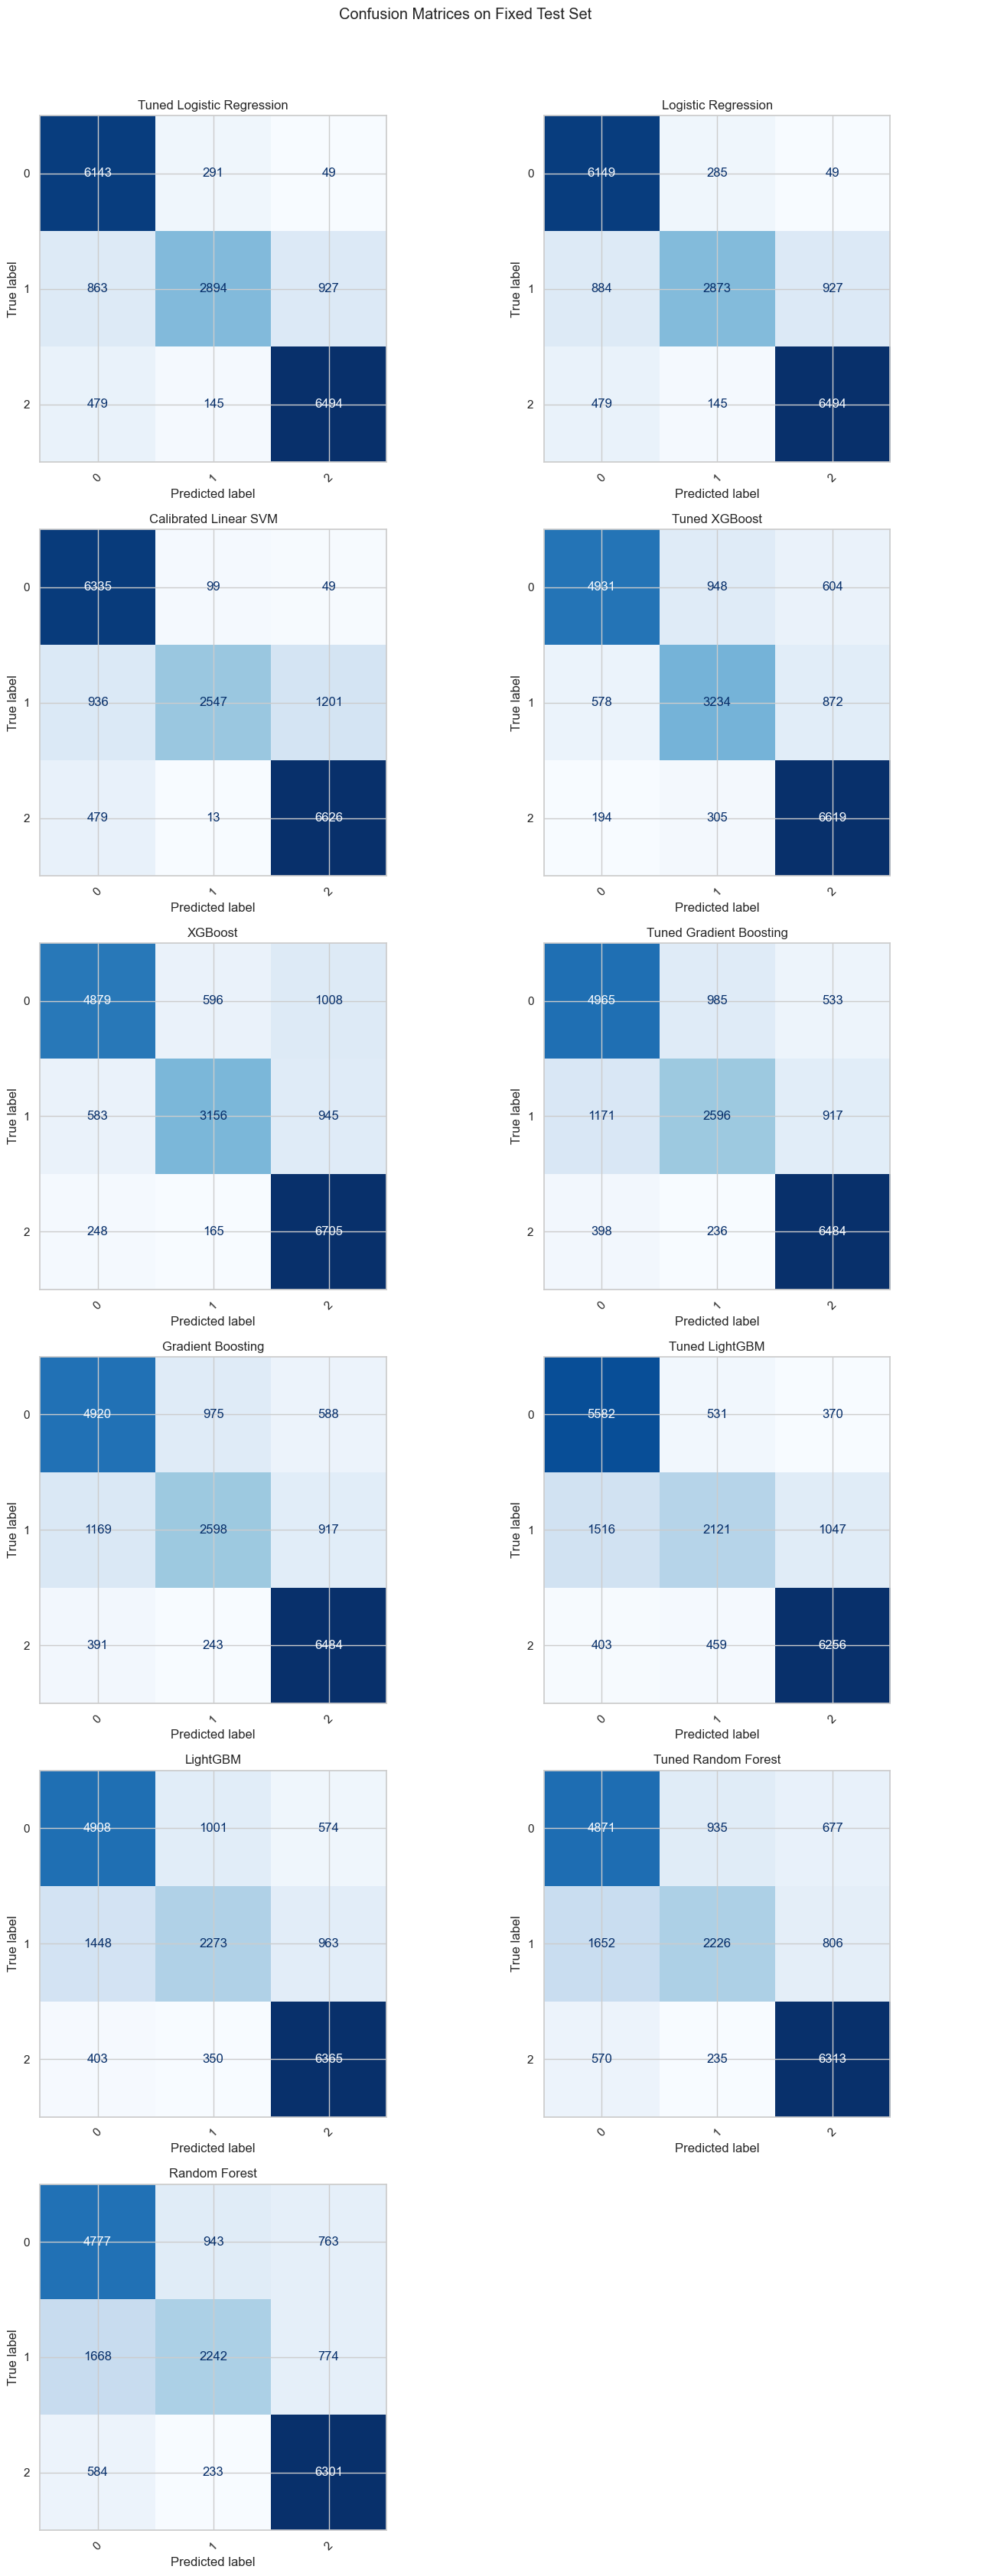

In [39]:
models_to_plot = evaluation_df["model"].tolist()
n_models = len(models_to_plot)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, test_predictions[model_name], labels=np.arange(n_classes))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(model_name)
    ax.tick_params(axis="x", rotation=45)

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Confusion Matrices on Fixed Test Set", y=1.02)
plt.tight_layout()
plt.show()

## 40. Comprehensive Testing on the Fixed Test Set - Classification Reports

In [40]:
for model_name in evaluation_df["model"]:
    print("=" * 100)
    print(model_name)
    print("=" * 100)
    print(classification_report(y_test, test_predictions[model_name], target_names=class_names, zero_division=0))

Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      6483
           1       0.87      0.62      0.72      4684
           2       0.87      0.91      0.89      7118

    accuracy                           0.85     18285
   macro avg       0.85      0.83      0.83     18285
weighted avg       0.85      0.85      0.84     18285

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      6483
           1       0.87      0.61      0.72      4684
           2       0.87      0.91      0.89      7118

    accuracy                           0.85     18285
   macro avg       0.85      0.82      0.83     18285
weighted avg       0.85      0.85      0.84     18285

Calibrated Linear SVM
              precision    recall  f1-score   support

           0       0.82      0.98      0.89      6483
           1       0.96      0.54      0.69      4684
       

## 41. ROC Curve Generation

For binary classification, the plot uses the positive-class score. For multiclass classification, it uses a one-vs-rest micro-average ROC curve for each model.

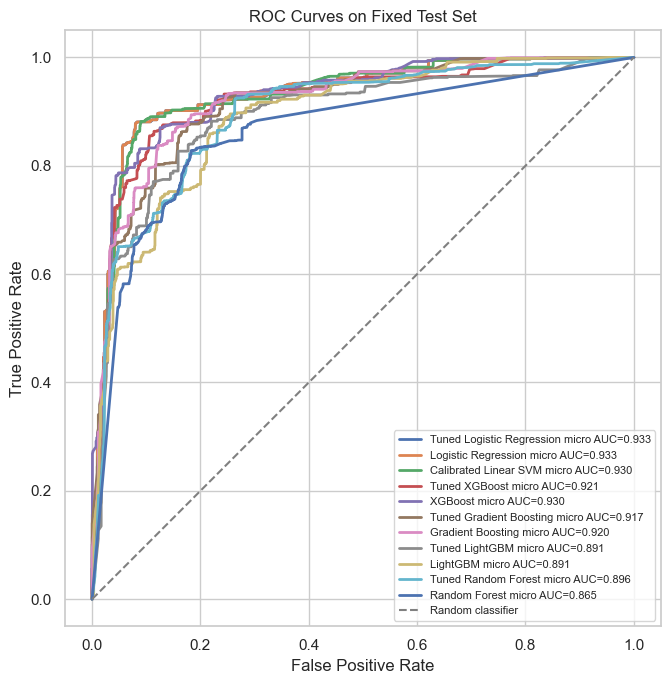

,model,roc_auc_curve
0,Tuned Logistic Regression,0.932825
1,Logistic Regression,0.932837
2,Calibrated Linear SVM,0.930017
3,Tuned XGBoost,0.920661
4,XGBoost,0.929688
5,Tuned Gradient Boosting,0.916599
6,Gradient Boosting,0.919681
7,Tuned LightGBM,0.890765
8,LightGBM,0.891341
9,Tuned Random Forest,0.895783


In [41]:
fig, ax = plt.subplots(figsize=(9, 7))
roc_plot_records = []

for model_name in evaluation_df["model"]:
    scores = test_score_matrices.get(model_name)
    if scores is None:
        continue

    scores = np.asarray(scores)

    try:
        if n_classes == 2:
            positive_scores = scores[:, 1] if scores.ndim == 2 else scores
            fpr, tpr, _ = roc_curve(y_test, positive_scores)
            model_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} AUC={model_auc:.3f}")
            roc_plot_records.append({"model": model_name, "roc_auc_curve": model_auc})
        else:
            if scores.ndim != 2 or scores.shape[1] != n_classes:
                continue
            y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))
            fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), scores.ravel())
            model_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} micro AUC={model_auc:.3f}")
            roc_plot_records.append({"model": model_name, "roc_auc_curve": model_auc})
    except ValueError as error:
        print(f"Skipping ROC curve for {model_name}: {error}")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
ax.set_title("ROC Curves on Fixed Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

roc_curve_summary = pd.DataFrame(roc_plot_records)
display(roc_curve_summary)

### ROC Curve Interpretation

Curves closer to the upper-left corner indicate stronger separation between classes. The dashed diagonal line represents a random classifier. For multiclass classification, the plotted curve summarizes one-vs-rest discrimination across classes using a micro-average strategy.

## 42. Model Comparison Summary

The primary model-selection metric is macro F1-score because it balances precision and recall across classes and is more robust than accuracy when classes are imbalanced. ROC-AUC and accuracy are used as secondary tie-breakers.

In [42]:
comparison_columns = ["model", "f1_macro", "precision_macro", "recall_macro", "roc_auc", "accuracy", "f1_weighted"]

model_comparison_df = evaluation_df[comparison_columns].copy()
model_comparison_df = model_comparison_df.sort_values(["f1_macro", "roc_auc", "accuracy"], ascending=False).reset_index(drop=True)

display(model_comparison_df)

,model,f1_macro,precision_macro,recall_macro,roc_auc,accuracy,f1_weighted
0,Tuned Logistic Regression,0.830713,0.853040,0.825913,0.907671,0.849385,0.843456
1,Logistic Regression,0.829494,0.852572,0.824727,0.907692,0.848564,0.842436
2,Calibrated Linear SVM,0.822576,0.872196,0.817272,0.904200,0.848127,0.837380
3,Tuned XGBoost,0.794911,0.801016,0.793645,0.912727,0.808532,0.806345
4,XGBoost,0.794730,0.811538,0.789448,0.917937,0.806125,0.802638
5,Tuned Gradient Boosting,0.745049,0.752410,0.743669,0.904128,0.768116,0.762308
6,Gradient Boosting,0.742929,0.750564,0.741497,0.906392,0.765764,0.759891
7,Tuned LightGBM,0.729485,0.747089,0.730913,0.879729,0.763413,0.751759
8,LightGBM,0.711999,0.719614,0.712179,0.868764,0.740826,0.732922
9,Tuned Random Forest,0.705056,0.717328,0.704497,0.882527,0.733388,0.725129


## 43. Best Final Model Selection

The best final model is selected by macro F1-score, then ROC-AUC, then accuracy. This avoids selecting a model based on accuracy alone.

In [43]:
best_model_name = model_comparison_df.iloc[0]["model"]
best_final_model = trained_models[best_model_name]

print(f"Best final model: {best_model_name}")
display(model_comparison_df.iloc[[0]])

Best final model: Tuned Logistic Regression


,model,f1_macro,precision_macro,recall_macro,roc_auc,accuracy,f1_weighted
0,Tuned Logistic Regression,0.830713,0.85304,0.825913,0.907671,0.849385,0.843456


## 44. Feature Importance or Interpretability Analysis

For models with intrinsic feature importance or linear coefficients, those values are plotted. If intrinsic importance is unavailable, permutation importance is computed on the fixed test set using macro F1-score.

,feature,importance
0,num__input_voltage,3.354263
1,num__time,0.331255


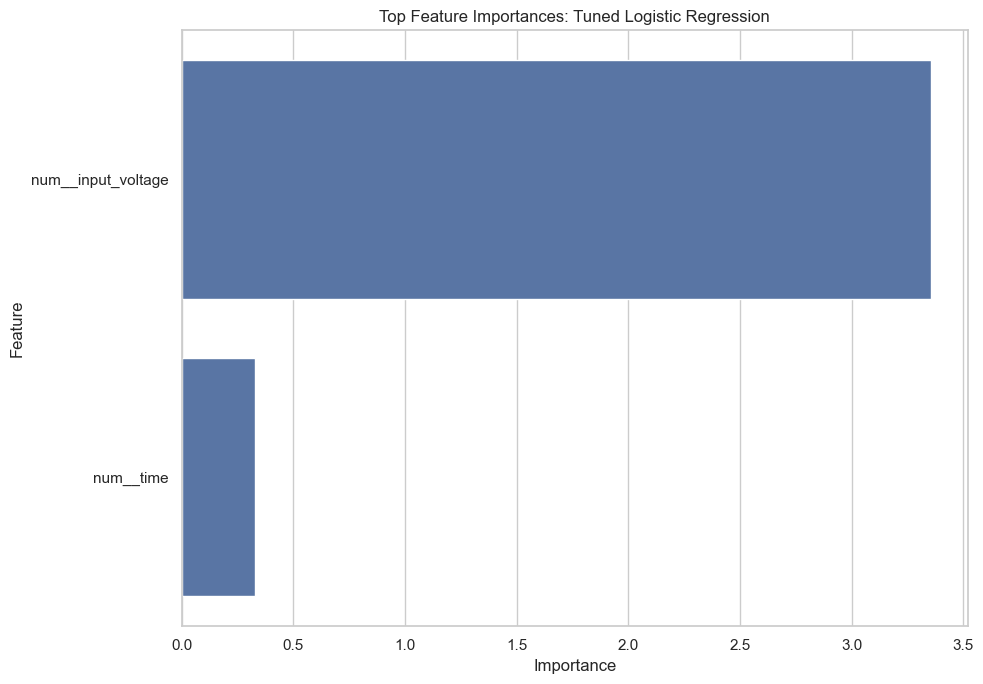

In [44]:
def get_feature_names_from_pipeline(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps.get("preprocessor")
    if preprocessor is not None and hasattr(preprocessor, "get_feature_names_out"):
        return preprocessor.get_feature_names_out()
    return np.array(feature_columns)


def intrinsic_importance_from_pipeline(pipeline: Pipeline) -> pd.DataFrame | None:
    if not isinstance(pipeline, Pipeline) or "classifier" not in pipeline.named_steps:
        return None

    classifier = pipeline.named_steps["classifier"]
    feature_names = get_feature_names_from_pipeline(pipeline)

    if hasattr(classifier, "feature_importances_"):
        importance_values = classifier.feature_importances_
    elif hasattr(classifier, "coef_"):
        coef = np.asarray(classifier.coef_)
        importance_values = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        return None

    if len(importance_values) != len(feature_names):
        return None

    return pd.DataFrame({"feature": feature_names, "importance": importance_values}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df = intrinsic_importance_from_pipeline(best_final_model)

if importance_df is None:
    print("Intrinsic importance unavailable. Computing permutation importance on the fixed test set.")
    permutation_result = permutation_importance(
        best_final_model,
        X_test_raw,
        y_test,
        scoring="f1_macro",
        n_repeats=8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = (
        pd.DataFrame(
            {
                "feature": X_test_raw.columns,
                "importance": permutation_result.importances_mean,
                "importance_std": permutation_result.importances_std,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

if importance_df is not None and not importance_df.empty:
    display(importance_df.head(30))
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature", ax=ax)
    ax.set_title(f"Top Feature Importances: {best_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance could not be computed for the selected model.")

## 45. Final Model Test-Set Evaluation

The selected model is evaluated one last time on the fixed test set.

In [45]:
final_evaluation = evaluate_classifier(best_model_name, best_final_model, X_test_raw, y_test)
display(pd.DataFrame([final_evaluation]))

print(classification_report(y_test, best_final_model.predict(X_test_raw), target_names=class_names, zero_division=0))

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc
0,Tuned Logistic Regression,0.849385,0.85304,0.825913,0.830713,0.85203,0.849385,0.843456,0.907671


              precision    recall  f1-score   support

           0       0.82      0.95      0.88      6483
           1       0.87      0.62      0.72      4684
           2       0.87      0.91      0.89      7118

    accuracy                           0.85     18285
   macro avg       0.85      0.83      0.83     18285
weighted avg       0.85      0.85      0.84     18285

